**Task**  
Let's look at a dataset which is about Cars_multivariate. It includes 392 cars with different features including mpg, cylinders, displacement, horsepower, weight, acceleration, model, origin and car_name.

The data is downloaded from [vincentarelbundock's github](https://vincentarelbundock.github.io/Rdatasets) and can be found in the project folder ('cars_multivariate.csv') 

The project is aimed to explore the relationship between the fuel efficiency of a car (mpg, miles-per-gallon) and other features.

## Multiple Linear Regression

##
Multiple Linear Regression is a supervised learning algorithm in machine learning.
Supervised learning → the dataset has features (X) and a target variable (y).
The model learns the relationship between X and y to predict a continuous value.

mpg =β0+β1(cylinders)+β2(displacement)+β3(horsepower)+β4(weight)+β5(acceleration)+β6(model)+β7(origin)+β8(car_name )

## Workflow



### Step 1: Load & inspect data

In [2]:
import pandas as pd

# read in cars dataset and mark all questionmarks as NaNs.
cars = pd.read_csv("cars_multivariate.csv")
                
cars.head(n=2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320


In [3]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model         392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car_name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 27.7+ KB


### Step 2: Correlation matrix → detect highly correlated features

In [4]:
# Calculate the correlation matrix for the cars dataset
import seaborn as sns
import matplotlib.pyplot as plt

corr = cars.corr(numeric_only=True)
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


### Visulization of the correlation matrix: 

From the heatmap we can see that cylinders, displacement, horsepower and weight are strongly correlated with each other! and two four factors have a strong negative effect on the mpg!

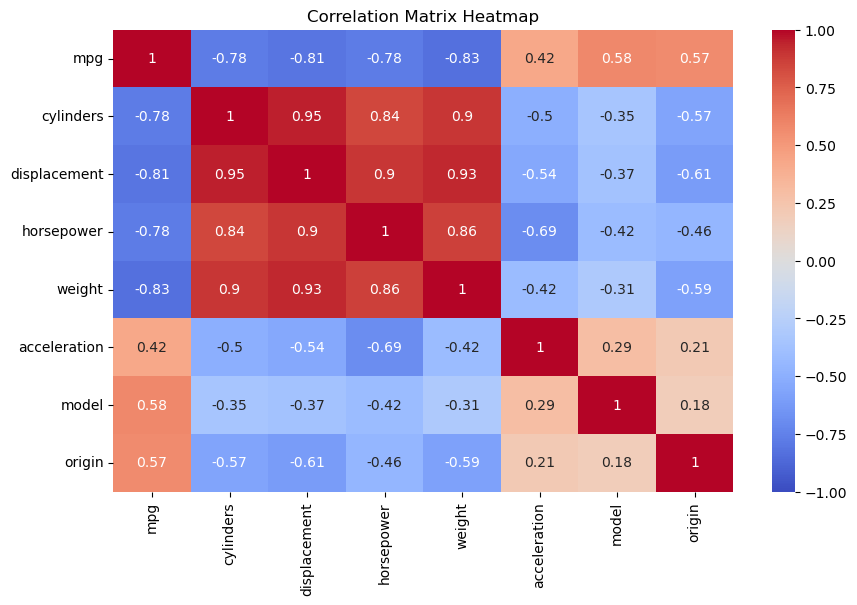

In [5]:
# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

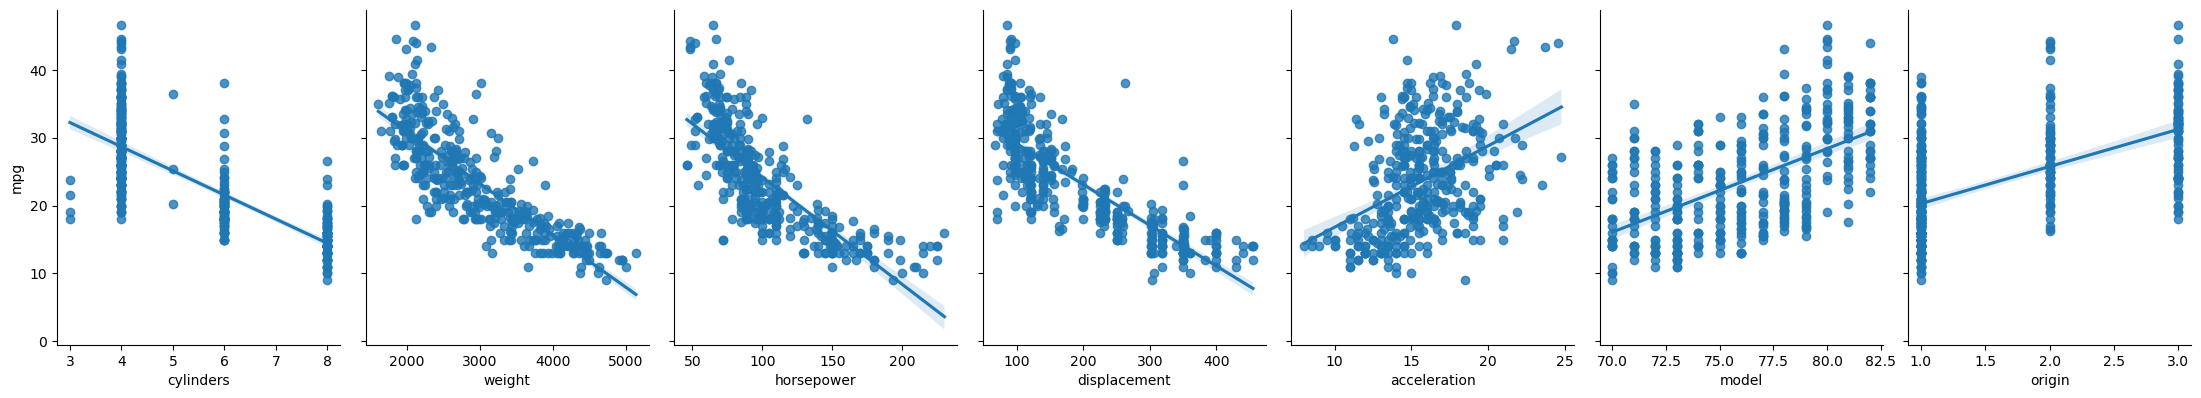

In [6]:
import seaborn as sns

# Pairplot
sns.pairplot(cars, x_vars=['cylinders','weight','horsepower','displacement','acceleration','model', 'origin'], y_vars='mpg', height=4, aspect=0.8, kind='reg')
plt.show()

### Step 3: VIF → quantify multicollinearity

We can see that cylinders & weight & horsepower & displacement have high VIF values which means that this predictor is highly collinear with others and might cause instability in a regression model predicting mpg.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X= cars[['cylinders','weight','horsepower','displacement','acceleration','model', 'origin']]
Y= cars['mpg']
X_const = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

       Variable         VIF
0         const  763.557531
1     cylinders   10.737535
2        weight   10.831260
3    horsepower    9.943693
4  displacement   21.836792
5  acceleration    2.625806
6         model    1.244952
7        origin    1.772386


### Step 4: Split Data into Training and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

X= cars[['cylinders','weight','horsepower','displacement','acceleration','model', 'origin']]
Y= cars['mpg']

# split into training and test sets, with 30% of the data reserved for testing and a random state of 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

### Step 5: Handle features (remove correlated, PCA, LASSO)

#### PCA

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
y = cars['mpg']

# Split into training and test sets, then scale and apply PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components selected:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Number of components selected: 4
Explained variance ratio: [0.66237253 0.13656454 0.09953067 0.06963919]


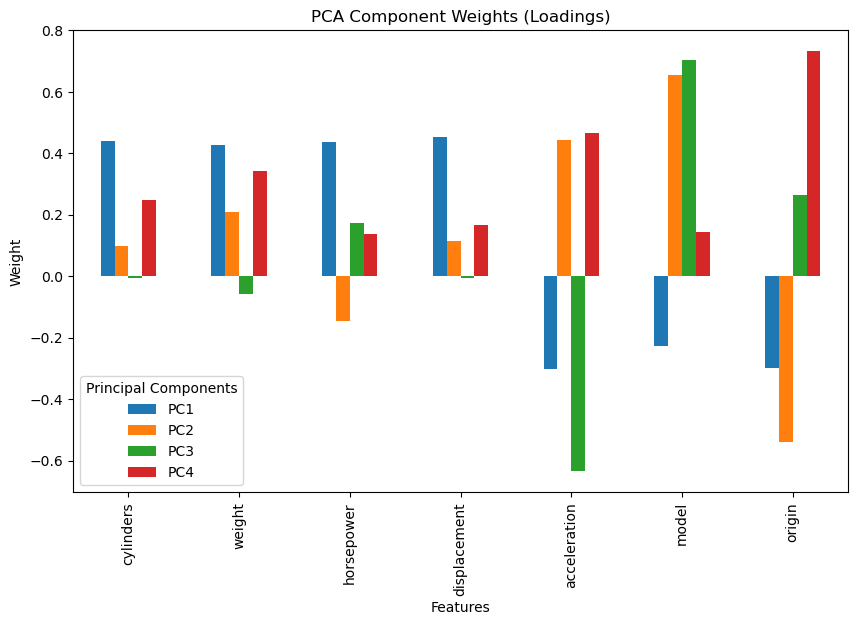

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

features = X.columns

pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

pca_components.T.plot(kind='bar', figsize=(10,6))

plt.title("PCA Component Weights (Loadings)")
plt.xlabel("Features")
plt.ylabel("Weight")
plt.legend(title="Principal Components")
plt.show()

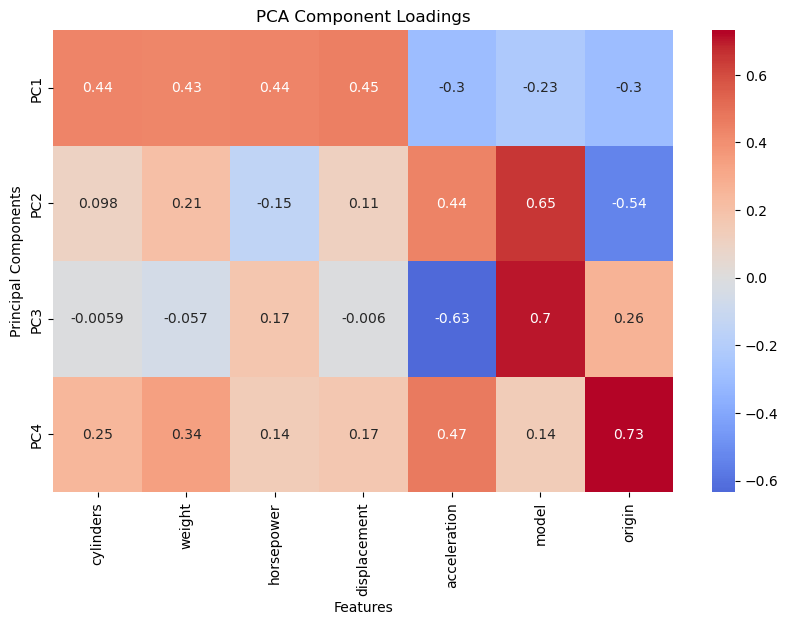

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    pca_components,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("PCA Component Loadings")
plt.xlabel("Features")
plt.ylabel("Principal Components")

plt.show()

#### Lasso Regression

In [12]:
from sklearn.linear_model import Lasso
import pandas as pd

X_lasso = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
Y_lasso = cars['mpg']

lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_lasso, Y_lasso)

# Create a dataframe to see coefficients
coef_df = pd.DataFrame({
    'Predictor': X_lasso.columns,
    'Coefficient': lasso_model.coef_
})

# Show predictors that Lasso kept (non-zero coefficients)
adopted_predictors = coef_df[coef_df['Coefficient'] != 0]
print("Predictors adopted by Lasso:")
print(adopted_predictors)

Predictors adopted by Lasso:
      Predictor  Coefficient
1        weight    -0.006492
2    horsepower    -0.006599
3  displacement     0.000474
5         model     0.706375
6        origin     0.007479


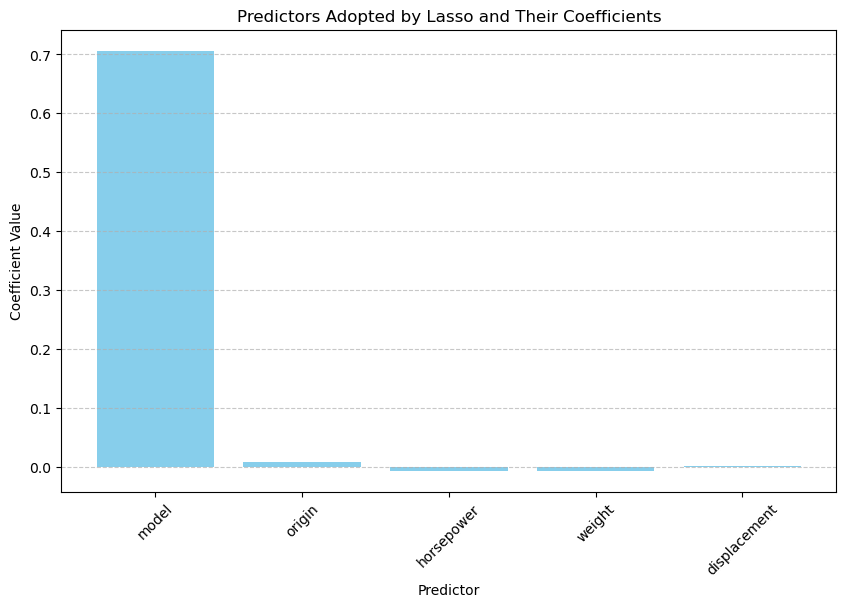

In [13]:
import matplotlib.pyplot as plt

# Sort predictors by absolute coefficient value
adopted_predictors_sorted = adopted_predictors.reindex(adopted_predictors['Coefficient'].abs().sort_values(ascending=False).index)

# Plot
plt.figure(figsize=(10,6))
plt.bar(adopted_predictors_sorted['Predictor'], adopted_predictors_sorted['Coefficient'], color='skyblue')
plt.title('Predictors Adopted by Lasso and Their Coefficients')
plt.ylabel('Coefficient Value')
plt.xlabel('Predictor')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Step 6: Train Models & Cross-Validation on Training Set

#### PCA: after K-fold cross validation on the training set, R² scores for each fold as well as the average R² are high which means all models generalize well on unseen data inside the training set.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Linear regression on PCA components
lr_pca = LinearRegression()

# Cross-validation on PCA components
scores = cross_val_score(lr_pca, X_train_pca, y_train, cv=5, scoring='r2') # Split X_train into 5 folds and compute R² as the scoring metric
print("Fold R² scores:", scores)
print("Average R² score:", np.mean(scores))

Fold R² scores: [0.80654847 0.72974533 0.74316464 0.81598667 0.80555541]
Average R² score: 0.7802001024476792


#### Training one final model using all the training dataset, and get the regression coefficients

In [15]:
# Fit the linear regression model on PCA components
lr_pca.fit(X_train_pca, y_train)

# Print coefficients and intercept of the linear regression model on PCA components
print("Intercept:", lr_pca.intercept_)
print("Coefficients:", lr_pca.coef_)

Intercept: 23.637591240875913
Coefficients: [-3.19519134  0.30332474  2.26430233 -0.30713578]


#### PCA regression equation: mpg=23.6376−3.1952⋅PC1​+0.3033⋅PC2​+2.2643⋅PC3​−0.3071⋅PC4​

In [16]:
import pandas as pd

coef_df = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(lr_pca.coef_))],
    "Coefficient": lr_pca.coef_
})

print("Intercept:", lr_pca.intercept_)
print(coef_df)

Intercept: 23.637591240875913
  Component  Coefficient
0       PC1    -3.195191
1       PC2     0.303325
2       PC3     2.264302
3       PC4    -0.307136


### Lasso Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# LASSO regression on original features
lr_lasso = Lasso(alpha=0.5)
lr_lasso.fit(X_train, y_train)

# Cross-validation on original features with LASSO
scores = cross_val_score(lr_lasso, X_train, y_train, cv=5, scoring='r2') # R² as the scoring metric
print("Fold R² scores:", scores)
print("LASSO CV R²:", np.mean(scores))

Fold R² scores: [0.78996906 0.74680335 0.76116263 0.82480583 0.8494081 ]
LASSO CV R²: 0.7944297961499573


#### Training one final model using all the training dataset, and get the regression coefficients

In [18]:
# LASSO regression on original features
lr_lasso = Lasso(alpha=0.5)
lr_lasso.fit(X_train, y_train)

# Print coefficients and intercept of the LASSO regression model on original features
print("Intercept:", lr_lasso.intercept_)
print("Coefficients:", lr_lasso.coef_)

Intercept: -8.538621869785409
Coefficients: [ 0.00000000e+00 -6.09973436e-03 -1.88603233e-02 -2.84497868e-04
  0.00000000e+00  6.82641151e-01  2.89162883e-01]


#### Lasso regression equation: mpg=10.309752604395523​−0.00649⋅weight−0.00660⋅horsepower+0.00047⋅displacement+0.70638⋅model+0.00748⋅origin

In [19]:
import pandas as pd

coef_df = pd.DataFrame({
    "Predictor": X_train.columns,
    "Coefficient": lr_lasso.coef_
})

print("Intercept:", lr_lasso.intercept_)
print(coef_df)

Intercept: -8.538621869785409
      Predictor  Coefficient
0     cylinders     0.000000
1        weight    -0.006100
2    horsepower    -0.018860
3  displacement    -0.000284
4  acceleration     0.000000
5         model     0.682641
6        origin     0.289163


### Step 7: Evaluate on Test Set

#### PCA

In [20]:

test_pca = lr_pca.score(X_test_pca, y_test)

print("Test R² PCA:", test_pca)

Test R² PCA: 0.7722452020221541


#### Lasso Regression

In [21]:
test_lasso = lr_lasso.score(X_test, y_test)

print("Test R² LASSO:", test_lasso)

Test R² LASSO: 0.8066878541413633


### Interpretation

For prediction purposes: Lasso is clearly the better choice here. It keeps the important predictors, shrinks irrelevant ones to zero, and avoids the potential information loss that can happen when using PCA components.

For interpretability: Lasso is also better than PCA, because the coefficients correspond to the original variables, so I can see exactly which predictors matter for mpg.

Why PCA might underperform here:
PCA creates linear combinations of all predictors, which can blur the influence of individual variables.
Some variance captured by PCs might not be relevant for predicting mpg, so the model could be less accurate.


### Conclusion: 

Lasso regression is outperforming PCA regression on both train and test sets.
Higher train R² → Lasso fits the training data well.
Higher test R² → Lasso generalizes better to unseen data, so it’s not overfitting compared to PCA regression.

### Prediction vs Actual 

#### PCA Model

In [22]:
from sklearn.linear_model import LinearRegression

lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)  # train on PCA-transformed training data

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# predict on PCA-transformed test data
y_pred_test= lr_pca.predict(X_test_pca) 

# Compare predicted vs actual
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print(comparison.head())

     Actual  Predicted
78     26.0  26.209946
274    21.6  27.917662
246    36.1  33.048111
55     26.0  24.149877
387    27.0  29.807942


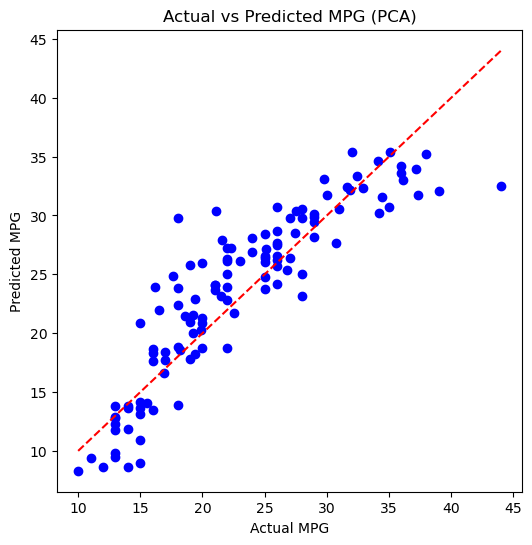

In [24]:
import matplotlib.pyplot as plt

# Predict values
y_pred_test = lr_pca.predict(X_test_pca) 

# Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (PCA)")
plt.show()

#### Lasso Model

In [25]:
X_lasso = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
Y_lasso = cars['mpg']

lr_lasso = Lasso(alpha=0.5)
lr_lasso.fit(X_lasso, Y_lasso)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [26]:
# predict on lasso test data
y_pred_test = lr_lasso.predict(X_test)

# Compare predicted vs actual
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print(comparison.head())

     Actual  Predicted
78     26.0  25.944483
274    21.6  25.957184
246    36.1  32.772433
55     26.0  26.740675
387    27.0  29.008042


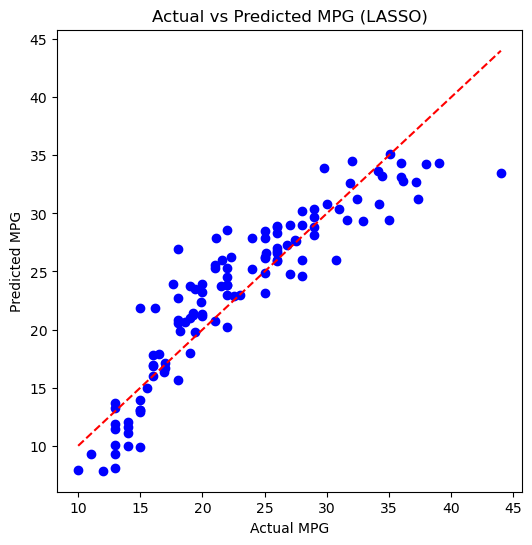

In [27]:
import matplotlib.pyplot as plt

# Predict values
y_pred_test = lr_lasso.predict(X_test)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (LASSO)")
plt.show()

### Random Forest: Non-linear model

### rank the feature importances

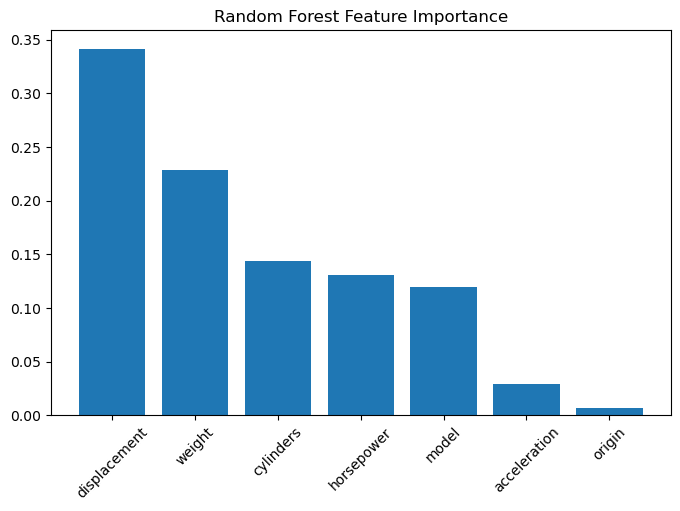

In [28]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Features and target
x = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
y = cars['mpg']

# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x, y)

# Feature importance
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(8,5))
plt.bar(feat_df['Feature'], feat_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45)
plt.show()

### Split data into train and test data


In [29]:
from sklearn.model_selection import train_test_split

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### Train Models & Cross-Validation on Training Set

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train Random Forest on training set
rf_model.fit(x_train, y_train)

# 5-Fold CV
scores = cross_val_score(rf_model, x_train, y_train, cv=5, scoring='r2')

print("R² scores for each fold:", scores)
print("Average R²:", scores.mean())

R² scores for each fold: [0.88650498 0.77871348 0.86529132 0.9138571  0.86636127]
Average R²: 0.8621456313602319


### Evaluate the model

In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_test)

print("Test R²:", r2)

Test R²: 0.8197594014767294


### Prediction vs Actual 

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train Random Forest on training set
rf_model.fit(x_train, y_train)

# Predict on test set
y_pred_test = rf_model.predict(X_test)

# Compare predicted vs actual
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_test})
print(comparison.head())

     Actual  Predicted
78     26.0     26.575
274    21.6     22.670
246    36.1     35.878
55     26.0     30.650
387    27.0     27.353


### Visualize predictions vs actual

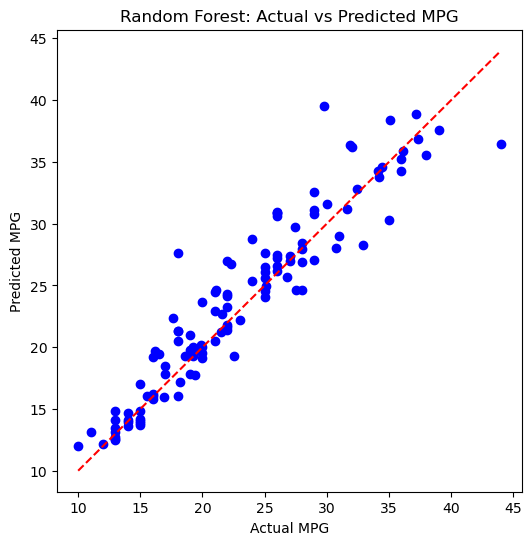

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Random Forest: Actual vs Predicted MPG")
plt.show()

### OPTION: Feature selection using RF

In [34]:
# Features and target
x = cars[['cylinders','weight','horsepower','displacement','acceleration','model','origin']]
y = cars['mpg']

# Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Feature importance
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feat_df['Feature'].head(5)  # top 5 features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf_model.fit(X_train_top, y_train)
y_pred_top = rf_model.predict(X_test_top)

# Compare predicted vs actual
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_top})
print(comparison.head())

     Actual  Predicted
78     26.0     26.079
274    21.6     22.303
246    36.1     37.255
55     26.0     31.214
387    27.0     28.168


In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_top)

print("Test R²:", r2)

Test R²: 0.864399985664773


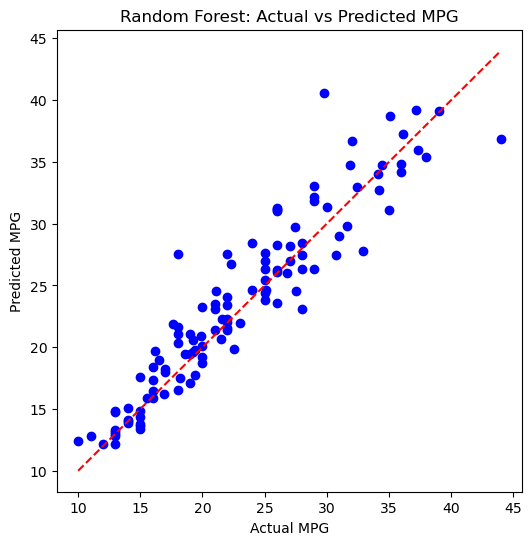

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_top, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linestyle='--')  # perfect prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Random Forest: Actual vs Predicted MPG")
plt.show()

##

When to Use PCA?

✅ Use PCA when:

many correlated features

educe dimensionality

don’t care about interpreting individual features

Example: compress 50 features into 5 principal components

⚠ Limitation:

PCA creates linear combinations of features → harder to explain in business terms


When to Use LASSO?

✅ Use LASSO when:

linear model

automatic feature selection (some coefficients shrink to 0)

Features are numeric and need scaling

Example: Identify which house features really affect price

⚠ Limitation:

Assumes linear relationship

Sensitive to feature scaling


When to Use Random Forest?

✅ Use Random Forest when:

flexible, non-linear model

rank feature importance

Features may have interactions or non-linear effects

Example: Predict house prices where area, age, distance, and rooms interact in complex ways

⚠ Limitation:

Harder to interpret exact relationships

Can overfit if parameters not tuned

## How to determine weather the relationships between features and targets are linear or non-linear?

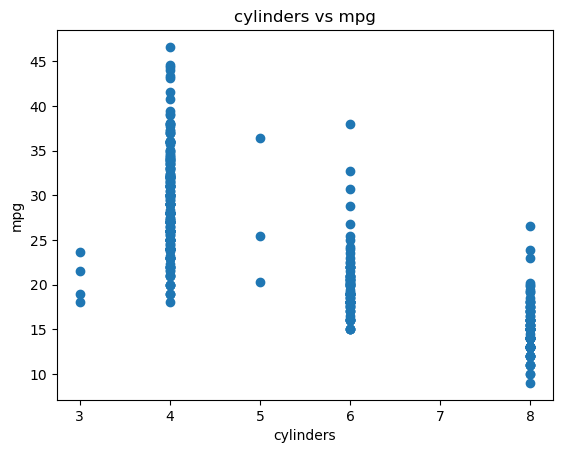

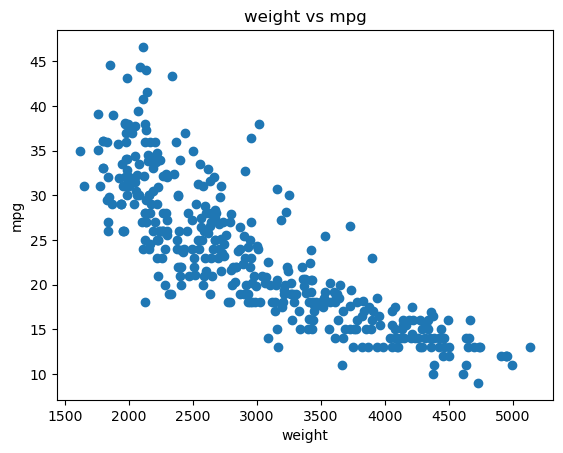

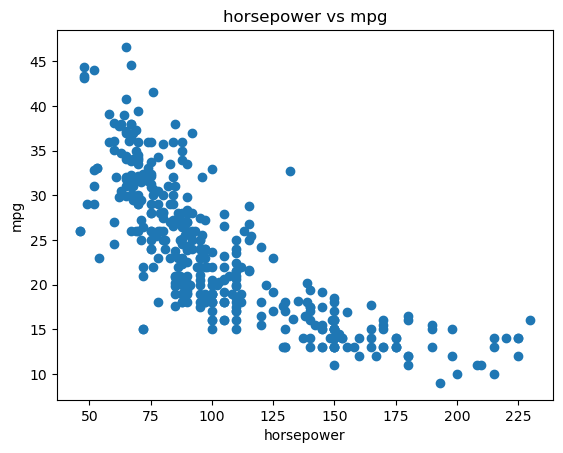

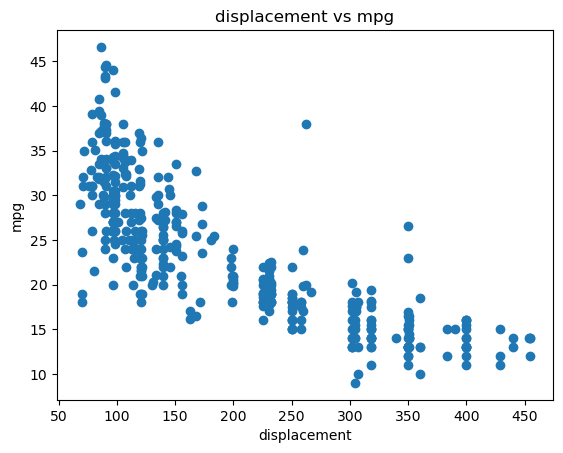

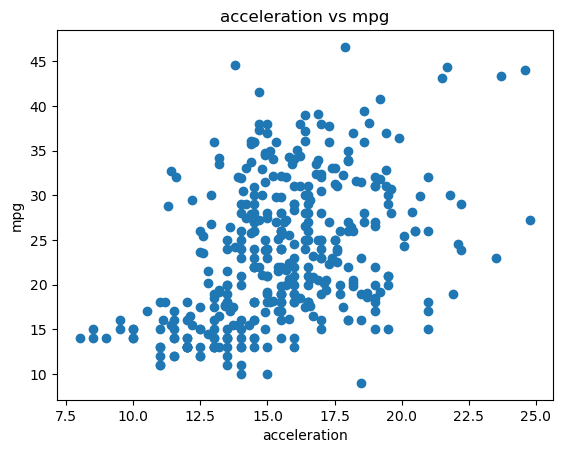

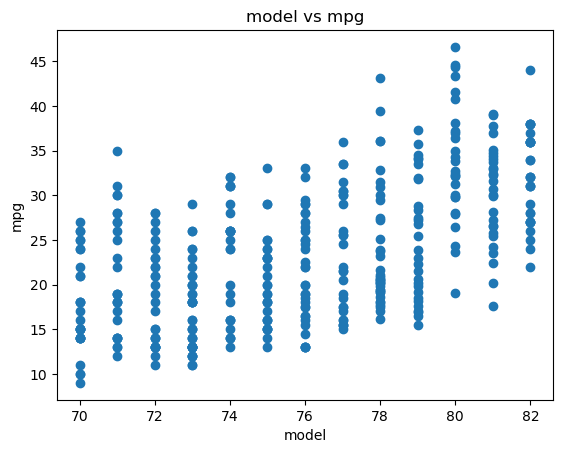

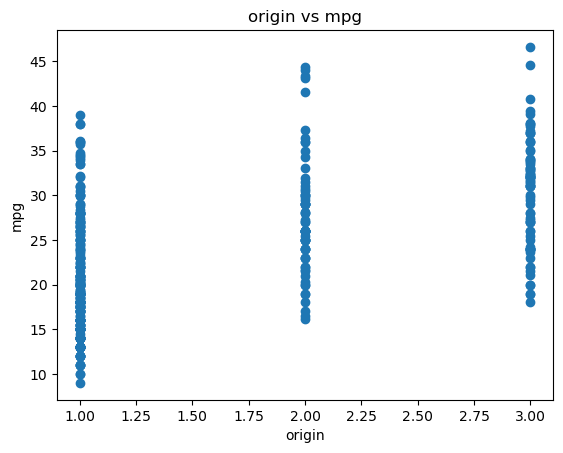

In [37]:
import matplotlib.pyplot as plt

features = ['cylinders','weight','horsepower','displacement','acceleration','model','origin']

for f in features:
    plt.figure()
    plt.scatter(cars[f], cars['mpg'])
    plt.xlabel(f)
    plt.ylabel('mpg')
    plt.title(f'{f} vs mpg')
    plt.show()

##

Random Forest or Gradient Boosting handle categorical or non-linear features automatically
No need to transform them
Interaction between categories and numeric features is captured naturally